# Head

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

proj_dir = Path.home() / "zqlyu"/ "projects" / "MolScanner"
data_dir = proj_dir / "data"

# Model

In [3]:
from MolScribe_re_model import MolScannerVocab
vocab = MolScannerVocab(n_bins=64)
print(len(vocab))

207


In [4]:
from MolScribe_re_model import MolScribeModel
model = MolScribeModel(vocab=vocab, backbone='swin_b', pretrained=True)
checkpoint = '20260226_edge_padding_finished'
model.load_model(str(proj_dir / "MolScanner" / "models" / "MolScribe_re" / f"{checkpoint}.pth"), device='cuda')

Model loaded from: /home/junjdong/zqlyu/projects/MolScanner/MolScanner/models/MolScribe_re/20260226_edge_padding_finished.pth


# Functions for SMILES pre-/post-preocessing

In [5]:
from rdkit import Chem

def remove_atom_mapping(smiles: str) -> str:
    """去除 SMILES 中的原子映射编号"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)

# Synthetic samples

## Data

In [6]:
import pickle

with open(data_dir / "pubchem_smiles/pubchem_smile_list.pkl", "rb") as f:
    pubchem_smile_list = pickle.load(f)

In [44]:
from MolScribe_re_model import MoleculeDataset
dataset = MoleculeDataset(vocab, pubchem_smile_list, 
                          shuffle_smiles=False, 
                          mol_augment=True,
                          geo_augment=True,
                          img_augment=True,
                          default_drawing_style=False)

## Input

torch.Size([3, 384, 384])
tensor(2.6400)


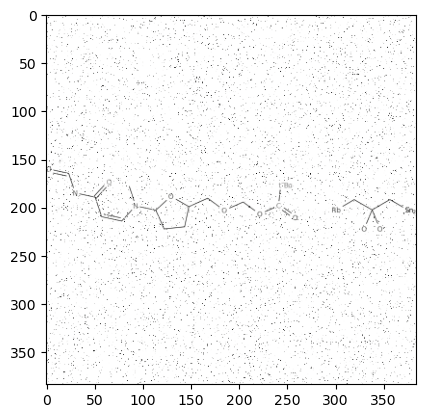

sequence length: 123
[1, 6, 119, 176, 68, 66, 49, 74, 5, 50, 67, 119, 172, 69, 68, 18, 115, 177, 6, 113, 175, 18, 109, 176, 6, 106, 174, 6, 103, 176, 57, 18, 100, 174, 6, 97, 176, 68, 17, 94, 176, 68, 75, 6, 92, 178, 70, 6, 88, 178, 76, 6, 87, 174, 68, 17, 84, 173, 6, 82, 170, 70, 18, 79, 169, 69, 70, 18, 89, 172, 69, 6, 93, 172, 69, 6, 99, 180, 6, 102, 179, 57, 69, 70, 18, 122, 178, 77, 6, 132, 175, 68, 66, 21, 31, 67, 129, 176, 69, 6, 135, 176, 68, 18, 136, 180, 69, 68, 18, 134, 180, 69, 6, 138, 175, 66, 22, 43, 58, 67, 141, 176, 2]
['<SOS>', 'C', '<X_BIN_40>', '<Y_BIN_33>', '(', '[', 't', '-', 'B', 'u', ']', '<X_BIN_40>', '<Y_BIN_29>', ')', '(', 'O', '<X_BIN_36>', '<Y_BIN_34>', 'C', '<X_BIN_34>', '<Y_BIN_32>', 'O', '<X_BIN_30>', '<Y_BIN_33>', 'C', '<X_BIN_27>', '<Y_BIN_31>', 'C', '<X_BIN_24>', '<Y_BIN_33>', '1', 'O', '<X_BIN_21>', '<Y_BIN_31>', 'C', '<X_BIN_18>', '<Y_BIN_33>', '(', 'N', '<X_BIN_15>', '<Y_BIN_33>', '(', '/', 'C', '<X_BIN_13>', '<Y_BIN_35>', '=', 'C', '<X_BIN_9>', '<Y

In [81]:
import random
 
sample = dataset[random.randint(0, len(dataset)-1)] 

from matplotlib import pyplot as plt
import torch

img_tensor = sample['img'] # [3, H, W]
print(img_tensor.shape)
print(img_tensor.max())

def denormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    img_tensor = img_tensor.clamp(0, 1) * 255.0
    return img_tensor.byte()

img_denorm = denormalize_img(img_tensor)

plt.imshow(img_denorm.permute(1, 2, 0).numpy())
plt.show()

print("sequence length:", len(sample['tok_id_seq']))
print(sample['tok_id_seq'])
print([vocab.idx2token[idx] for idx in sample['tok_id_seq']])
print("bond matrix shape:", sample['bond_mat'].shape)
print(sample['bond_mat'])
print(vocab.sequence_to_smiles(sample['tok_id_seq']))

## Predicton

In [82]:
import numpy as np

result_post = model.predict(sample['img'], device='cuda', beam_size=1)
print("sequence length:", len(result_post['token_ids']))
print(result_post['token_ids'])
print(result_post['smiles'])
print("atom number:", len(result_post['symbols']))
print("symbols:", result_post['symbols'])
print("bond matrix shape:", result_post['bond_mat'].shape)
print(result_post['bond_mat'])
is_symmetric = np.allclose(result_post['bond_mat'], result_post['bond_mat'].T)
print(f"Bond marix is symmetric: {is_symmetric}")

print(result_post['success'])

result_decoder = model.predict(sample['img'], device='cuda', beam_size=1, smiles_mode="decoder")
result_graph = model.predict(sample['img'], device='cuda', beam_size=1, smiles_mode="graph")

sequence length: 126
[1, 6, 119, 176, 68, 66, 38, 74, 5, 50, 67, 119, 172, 69, 68, 18, 115, 177, 6, 113, 175, 18, 109, 176, 6, 106, 174, 6, 103, 176, 57, 18, 100, 174, 6, 97, 176, 68, 17, 94, 176, 68, 75, 6, 92, 178, 70, 6, 88, 178, 76, 6, 87, 174, 68, 17, 83, 174, 6, 82, 170, 70, 18, 79, 169, 69, 70, 18, 89, 172, 69, 6, 93, 172, 69, 6, 99, 180, 6, 102, 179, 57, 69, 70, 18, 122, 178, 77, 6, 132, 175, 68, 66, 21, 31, 67, 129, 176, 69, 6, 135, 176, 68, 66, 18, 74, 67, 136, 180, 69, 68, 18, 134, 180, 69, 6, 138, 175, 66, 22, 19, 44, 67, 141, 176, 2]
C([i-Bu])(OCOCC1OC(N(/C=C\C(NC=O)=O)C)CC1)=O.C([Rb])C([O-])(O)C[SPo]
atom number: 28
symbols: ['C', '[i-Bu]', 'O', 'C', 'O', 'C', 'C', 'O', 'C', 'N', 'C', 'C', 'C', 'N', 'C', 'O', 'O', 'C', 'C', 'C', 'O', 'C', '[Rb]', 'C', '[O-]', 'O', 'C', '[SPo]']
bond matrix shape: (28, 28)
[[0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

Groundtruth SMILES:
 C([t-Bu])(OCOCC1OC(N(/C=C\C(NC=O)=O)C)CC1)=O.C([Rb])C(O)(O)C[Sn2]
Decoder SMILES:
 C([i-Bu])(OCOCC1OC(N(/C=C\C(NC=O)=O)C)CC1)=O.C([Rb])C([O-])(O)C[SPo]
Graph SMILES:
 C([i-Bu])(OCOCC1OC(N(/C=C\C(NC=O)=O)C)CC1)=O.C([Rb])C([O-])(O)C[SPo]
Postprocess SMILES:
 C([i-Bu])(OCOCC1OC(N(/C=C\C(NC=O)=O)C)CC1)=O.C([Rb])C([O-])(O)C[SPo]

Canonical Groundtruth SMILES:
 *C(=O)OCOCC1CCC(N(C)/C=C\C(=O)NC=O)O1.*CC(O)(O)[CH2][Rb]
Canonical Postprocess SMILES:
 *C(=O)OCOCC1CCC(N(C)/C=C\C(=O)NC=O)O1.*CC([O-])(O)[CH2][Rb]
Canonical SMILES match: False


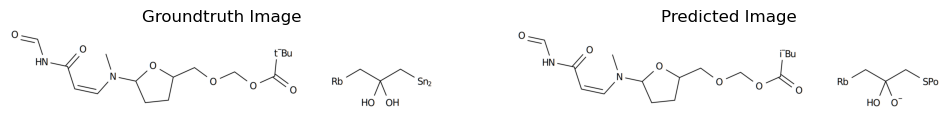

In [83]:
from drawing_engine import generate_image_from_graph
from chemistry import canonicalize_smiles

smiles_gt = vocab.sequence_to_smiles(sample['tok_id_seq'])['smiles']
print("Groundtruth SMILES:\n", smiles_gt)
symbols = vocab.sequence_to_smiles(sample['tok_id_seq'])['symbols']
coords = vocab.sequence_to_smiles(sample['tok_id_seq'])['coords']
img_gt, _, _, success = generate_image_from_graph({'symbols': symbols, 'coords': coords, 'edges': sample['bond_mat']}, debug=True)

smiles_decoder = result_decoder['smiles']
print("Decoder SMILES:\n", smiles_decoder)
smiles_graph = result_graph['smiles']
print("Graph SMILES:\n", smiles_graph)
smiles_post = result_post['smiles']
print("Postprocess SMILES:\n", smiles_post)

symbols = result_post['symbols']
coords = result_post['coords']
img_pred, _, _, success = generate_image_from_graph({'symbols': symbols, 'coords': coords, 'edges': result_post['bond_mat']}, debug=False)

smiles_gt_canonical, _ = canonicalize_smiles(remove_atom_mapping(smiles_gt))
smiles_pred_canonical,_  = canonicalize_smiles(remove_atom_mapping(smiles_post))
print("\nCanonical Groundtruth SMILES:\n", smiles_gt_canonical)
print("Canonical Postprocess SMILES:\n", smiles_pred_canonical)
print("Canonical SMILES match:", smiles_gt_canonical == smiles_pred_canonical)

from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gt, cmap='gray')
axes[0].set_title('Groundtruth Image')
axes[0].axis('off')

axes[1].imshow(img_pred, cmap='gray')
axes[1].set_title('Predicted Image')
axes[1].axis('off')
plt.show()

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

gt_mol = Chem.MolFromSmiles(smiles_gt_canonical)
pred_mol = Chem.MolFromSmiles(smiles_pred_canonical)

if gt_mol and pred_mol:
    gt_fp = AllChem.GetMorganFingerprintAsBitVect(gt_mol, 2, nBits=1024)
    pred_fp = AllChem.GetMorganFingerprintAsBitVect(pred_mol, 2, nBits=1024)
    tanimoto = DataStructs.TanimotoSimilarity(gt_fp, pred_fp)
    print(f"Tanimoto Similarity: {tanimoto}")
else:
    print("Invalid SMILES")

Invalid SMILES


# Benchmark

In [227]:
import pandas as pd
from IPython.display import display

benchmark_type = 'real'
benchmark_name = 'USPTO'
benchmark_dir = data_dir / "benchmark" / benchmark_type / benchmark_name

with open(data_dir / 'benchmark' / benchmark_type / f'{benchmark_name}.csv') as f:
    label_df = pd.read_csv(f)
display(label_df)

,image_id,file_path,SMILES
0,US07323448-20080129-C00047,real/USPTO/US07323448-20080129-C00047.png,[H]C(=O)N(O)CC(C)C(=O)N[C@H](C(=O)N(C)C)C(C)(C)C
1,USRE039991-20080101-C00307,real/USPTO/USRE039991-20080101-C00307.png,COC1=C(O)C(C(=O)NC2=CC=CC(OC3=CC=C(C)C=C3)=C2)...
2,US07319109-20080115-C00110,real/USPTO/US07319109-20080115-C00110.png,COC(=O)C1=CC=CC(OCC2=CC=C(OCC3=C(C(C)C)ON=C3C3...
3,US07319111-20080115-C00039,real/USPTO/US07319111-20080115-C00039.png,CC1=CC(C)=C(NS(=O)(=O)C2=C(Cl)C=CC=C2)C(C)=C1N...
4,US07314887-20080101-C00137,real/USPTO/US07314887-20080101-C00137.png,CCC1=CC=C(N2C(=O)/C(=N\NC3=CC=CC(C4=CC(C(=O)O)...
...,...,...,...
5714,US07319104-20080115-C00422,real/USPTO/US07319104-20080115-C00422.png,CC(C)(OC1=CC=C(CCN(CC2=CC=C(OC(F)(F)F)C=C2)C2=...
5715,US07319104-20080115-C00385,real/USPTO/US07319104-20080115-C00385.png,CC(C)(OC1=CC=C(CCN(CC2=CC=C(C3=NOC(C4CC4)=N3)C...
5716,USRE039991-20080101-C00179,real/USPTO/USRE039991-20080101-C00179.png,[H][C@@]12CCCC(NC(=O)C3=NC=CC(OC)=C3O)[C@]1([H...
5717,US07314885-20080101-C00026,real/USPTO/US07314885-20080101-C00026.png,O=C(NC1=CC=CC=C1)C1=CC(C2=CN=CN2C2=CC=CC(F)=C2...


## Reload the model

In [146]:
from MolScribe_re_model import MolScribeModel

model = MolScribeModel(vocab=vocab, backbone='swin_b', pretrained=True)
checkpoint = 'best'
model.load_model(str(proj_dir / "MolScanner" / "models" / "MolScribe_re"/ f"{checkpoint}.pth"), device='cuda')

Model loaded from: /home/zqlyu2/projects/Markush/MolScanner/models/MolScribe_re/best.pth


## Single

### Prediction

input image size: (261, 262, 3)
0 255 uint8


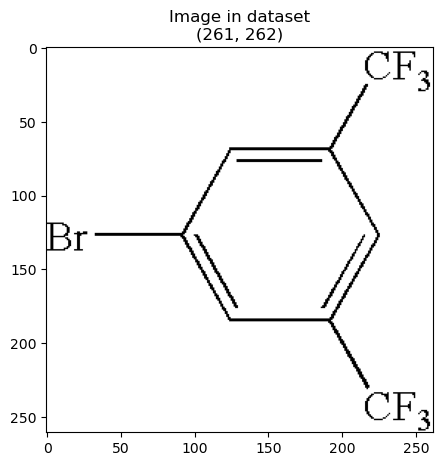

Original Ground truth SMILES: FC(F)(F)C1=CC(Br)=CC(C(F)(F)F)=C1
Ground truth SMILES canonicalization successful: True
tensor(-2.1179) tensor(2.6400) torch.float32
output token_id sequence length: 47
Predicted atom symbols: ['C', 'C', 'Br', 'C', 'C', '[CF3]', 'C', 'C', '[CF3]']
Predicted bond matrix is symmetric: True
Predicted image generation successful: True


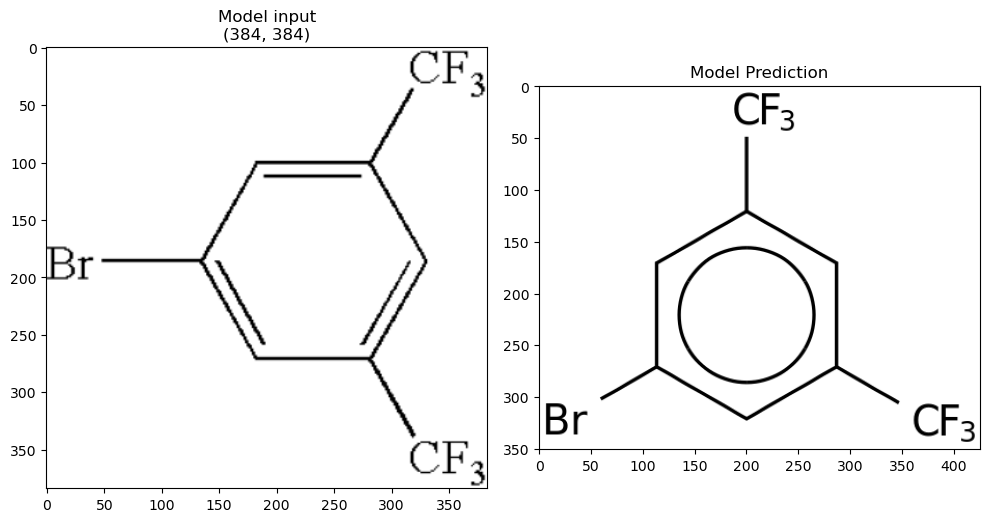

Predicted SMILES:
 FC(F)(F)c1cc(Br)cc(C(F)(F)F)c1
Predicted SMILES canonicalization successful: True
Ground Truth: FC(F)(F)c1cc(Br)cc(C(F)(F)F)c1
Predicted:    FC(F)(F)c1cc(Br)cc(C(F)(F)F)c1
Match: True


In [ ]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from drawing_engine import generate_image_from_graph
from chemistry import _convert_graph_to_smiles
from chemistry import canonicalize_smiles
import cv2

random_row = label_df.sample(n=1).iloc[0]
img_id = random_row['image_id']
random_png = benchmark_dir / f"{img_id}.png"
print("input image size:", cv2.imread(str(random_png)).shape)
print(cv2.imread(str(random_png)).min(), cv2.imread(str(random_png)).max(), cv2.imread(str(random_png)).dtype)

# Original image in dataset
fig1, ax1 = plt.subplots(figsize=(5, 5))
ax1.imshow(cv2.cvtColor(cv2.imread(str(random_png)), cv2.COLOR_BGR2RGB))
ax1.set_title(f'Image in dataset\n{cv2.imread(str(random_png)).shape[:2]}')
# ax1.axis('off')
plt.show()

# Ground truth SMILES
raw_ground_truth_smiles = random_row['SMILES']
print("Original Ground truth SMILES:", raw_ground_truth_smiles)
ground_truth_smiles = remove_atom_mapping(raw_ground_truth_smiles)
ground_truth_smiles, success = canonicalize_smiles(ground_truth_smiles, ignore_cistrans=True)
print("Ground truth SMILES canonicalization successful:", success)

result_post = model.predict(str(random_png), device='cuda', beam_size=1, return_preprocessed=True)

print(result_post['preprocessed_img'].min(), result_post['preprocessed_img'].max(), result_post['preprocessed_img'].dtype)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# 反归一化用于显示
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
img_display = result_post['preprocessed_img'] * std[:, None, None] + mean[:, None, None]
img_display = img_display.permute(1, 2, 0).numpy()
img_display = np.clip(img_display, 0, 1)
axes[0].imshow(img_display)
axes[0].set_title(f'Model input\n{img_display.shape[:2]}')
# axes[0].axis('off')

print("output token_id sequence length:", len(result_post['token_ids']))
# New format: [symbol, x, y, symbol, x, y, ...]
symbols = result_post['symbols']
coords = result_post['coords']
print("Predicted atom symbols:", symbols)
is_symmetric = np.allclose(result_post['bond_mat'], result_post['bond_mat'].T)
print(f"Predicted bond matrix is symmetric: {is_symmetric}")
img_pred, _, _, success = generate_image_from_graph({'symbols': symbols, 'coords': coords, 'edges': result_post['bond_mat']}, debug=True)
print("Predicted image generation successful:", success)

axes[1].imshow(img_pred, cmap='gray')
axes[1].set_title('Model Prediction')
# axes[1].axis('off')

plt.tight_layout()
plt.show()

pred_smiles, _, _, _ = _convert_graph_to_smiles(coords=coords, symbols=symbols, edges=result_post['bond_mat'])
pred_smiles, success = canonicalize_smiles(pred_smiles, ignore_cistrans=True)
print("Predicted SMILES:\n", pred_smiles)
print("Predicted SMILES canonicalization successful:", success)
print(f"Ground Truth: {ground_truth_smiles}")
print(f"Predicted:    {pred_smiles}")
print(f"Match: {ground_truth_smiles == pred_smiles}")

In [221]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

gt_mol = Chem.MolFromSmiles(ground_truth_smiles)
pred_mol = Chem.MolFromSmiles(pred_smiles)

if gt_mol and pred_mol:
    gt_fp = AllChem.GetMorganFingerprintAsBitVect(gt_mol, 2, nBits=1024)
    pred_fp = AllChem.GetMorganFingerprintAsBitVect(pred_mol, 2, nBits=1024)
    tanimoto = DataStructs.TanimotoSimilarity(gt_fp, pred_fp)
    print(f"Tanimoto Similarity: {tanimoto}")
else:
    print("Invalid SMILES")

Tanimoto Similarity: 1.0


Using device: cuda
GT image generated: True, Pred image generated: True
GT rendered vs Pred rendered  — distance: 0.0000, same: True
Pred rendered vs Original input — distance: 1.4976, same: False
GT rendered vs Original input — distance: 1.4976, same: False


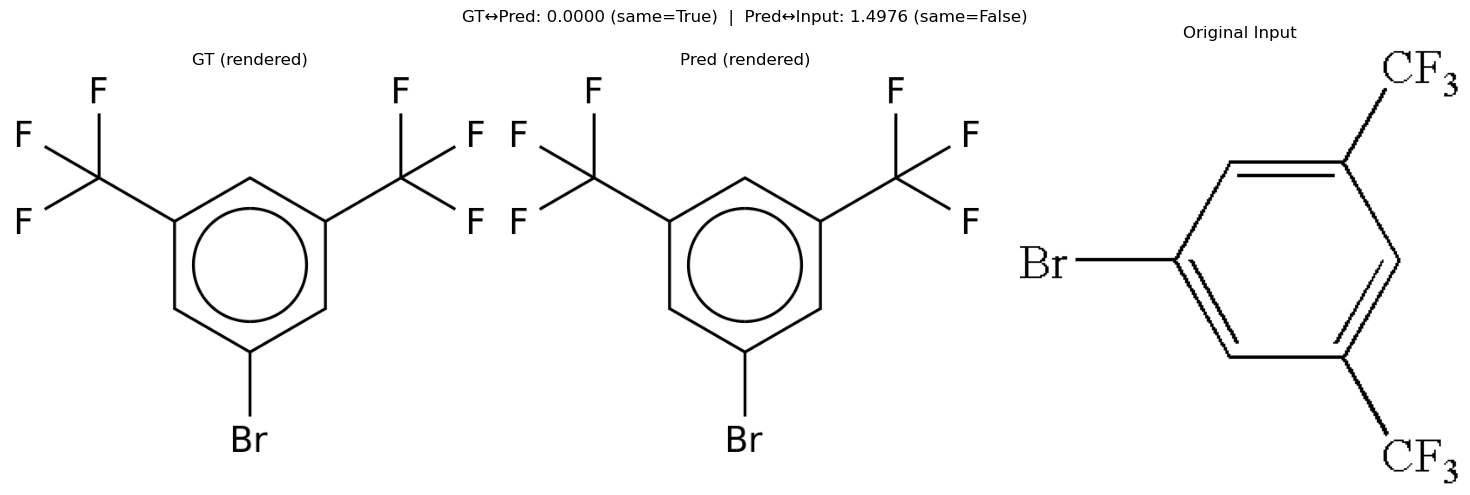

In [229]:
from MolDiscriminator_model import MoleculeDiscriminator
from drawing_engine import generate_image_from_smiles

# Load MolDiscriminator
discriminator = MoleculeDiscriminator(device=torch.device('cuda'))
discriminator.load_model(str(proj_dir / "MolScanner" / "models" / "MolDiscriminator" / "20260223_curriculum.pth"))

# Generate images from SMILES
gt_img, _, _, gt_success, _, _ = generate_image_from_smiles(ground_truth_smiles, mol_augment=False, default_drawing_style=True)
pred_img, _, _, pred_success, _, _ = generate_image_from_smiles(pred_smiles, mol_augment=False, default_drawing_style=True)
print(f"GT image generated: {gt_success}, Pred image generated: {pred_success}")

# Read the original input image (RGB)
original_input_img = cv2.cvtColor(cv2.imread(str(random_png)), cv2.COLOR_BGR2RGB)

# Compute embedding distances
is_same_gt_pred, dist_gt_pred = discriminator.predict(gt_img, pred_img)
is_same_pred_input, dist_pred_input = discriminator.predict(pred_img, original_input_img)
is_same_gt_input, dist_gt_input = discriminator.predict(gt_img, original_input_img)

print(f"GT rendered vs Pred rendered  — distance: {dist_gt_pred:.4f}, same: {is_same_gt_pred}")
print(f"Pred rendered vs Original input — distance: {dist_pred_input:.4f}, same: {is_same_pred_input}")
print(f"GT rendered vs Original input — distance: {dist_gt_input:.4f}, same: {is_same_gt_input}")

# Show all three images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_img)
axes[0].set_title('GT (rendered)')
axes[0].axis('off')
axes[1].imshow(pred_img)
axes[1].set_title('Pred (rendered)')
axes[1].axis('off')
axes[2].imshow(original_input_img)
axes[2].set_title('Original Input')
axes[2].axis('off')
plt.suptitle(f'GT↔Pred: {dist_gt_pred:.4f} (same={is_same_gt_pred})  |  Pred↔Input: {dist_pred_input:.4f} (same={is_same_pred_input})')
plt.tight_layout()
plt.show()

### To check if the benchmark itself is wrong

Label: CCOC(=O)CCC1=CC=C(C=C1C(F)(F)F)[C@@H]1CC(=O)CC1
Prediction: CCOC(=O)CCc1ccc([C@@H]2CCC(=O)C2)cc1C(F)(F)F


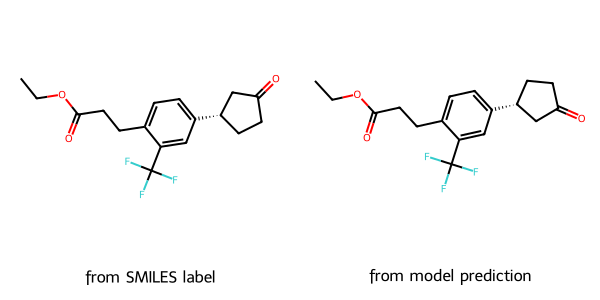

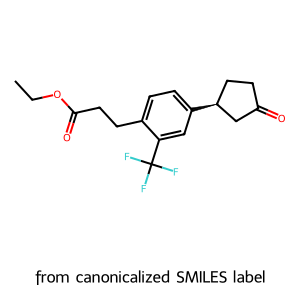

In [223]:
from rdkit import Chem
from rdkit.Chem import Draw

raw_gt_mol = Chem.MolFromSmiles(raw_ground_truth_smiles)
pred_mol = Chem.MolFromSmiles(pred_smiles)
print("Label:", raw_ground_truth_smiles)
print("Prediction:", pred_smiles)

img = Draw.MolsToGridImage([raw_gt_mol, pred_mol], 
                            molsPerRow=2, 
                            subImgSize=(300, 300),
                            legends=['from SMILES label', 'from model prediction'])

display(img)

gt_mol = Chem.MolFromSmiles(ground_truth_smiles)
img = Draw.MolsToImage([gt_mol], 
                       subImgSize=(300, 300),
                       legends=['from canonicalized SMILES label'])
display(img)

## Batch

In [ ]:
from MolScanner_model import MolScannerVocab, MolScannerModel, evaluate_benchmarks

vocab = MolScannerVocab(n_bins=64)
model = MolScannerModel(vocab=vocab, backbone='swin_b', pretrained=True)
checkpoint = 'best'
model.load_model(str(proj_dir / "MolScanner" / "models" / "MolScanner" / f"{checkpoint}.pth"), device='cuda')

benchmarks = [
    {'name': 'indigo', 'benchmark_dir': str(data_dir / "benchmark/synthetic/indigo"), 'csv_path': str(data_dir / "benchmark/synthetic/indigo.csv")},
    {'name': 'chemdraw', 'benchmark_dir': str(data_dir / "benchmark/synthetic/chemdraw"), 'csv_path': str(data_dir / "benchmark/synthetic/chemdraw.csv")},
    {'name': 'CLEF',  'benchmark_dir': str(data_dir / "benchmark/real/CLEF"),  'csv_path': str(data_dir / "benchmark/real/CLEF.csv")},
    {'name': 'UOB',   'benchmark_dir': str(data_dir / "benchmark/real/UOB"),   'csv_path': str(data_dir / "benchmark/real/UOB.csv")},
    {'name': 'USPTO', 'benchmark_dir': str(data_dir / "benchmark/real/USPTO"), 'csv_path': str(data_dir / "benchmark/real/USPTO.csv")},
    {'name': 'staker', 'benchmark_dir': str(data_dir / "benchmark/real/staker"), 'csv_path': str(data_dir / "benchmark/real/staker.csv")},
    {'name': 'acs',   'benchmark_dir': str(data_dir / "benchmark/real/acs"),   'csv_path': str(data_dir / "benchmark/real/acs.csv")},
]

results = evaluate_benchmarks(model, benchmarks, beam_size=1)

Model loaded from: /home/zqlyu2/projects/Markush/MolScanner/models/MolScanner/best.pth

Benchmark: indigo
  Images: 5719
Distributing 5719 images across 4 GPUs...


GPU-0: 100%|██████████| 12/12 [09:51<00:00, 49.26s/it]


  Post-processing [decoder] ...


  decoder: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 5719/5719 [00:00<00:00, 283573.80it/s]


  [indigo/decoder    ] Exact Match: 87.71% Tanimoto: 0.9926  Failed: 31
  Post-processing [graph] ...


...

  graph: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 5719/5719 [00:00<00:00, 217733.14it/s]


  [USPTO/graph      ] Exact Match: 74.33% Tanimoto: 0.8527  Failed: 585
  Post-processing [postprocess] ...


  postprocess: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 5719/5719 [00:06<00:00, 893.57it/s]


  [USPTO/postprocess] Exact Match: 76.61% Tanimoto: 0.8820  Failed: 391

Benchmark: staker
  Images: 50000
Distributing 50000 images across 4 GPUs...


GPU-0:  41%|████      | 40/98 [28:46<40:51, 42.26s/it]  